In [51]:
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure Python can find Reinforcement_learning_partie/preprocess.py
project_root = Path.cwd().resolve().parent
preprocess_dir = project_root / "Reinforcement_learning_partie"
if str(preprocess_dir) not in sys.path:
    sys.path.insert(0, str(preprocess_dir))

# Reload module so latest modifications are always used.
import preprocess as preprocess_module
importlib.reload(preprocess_module)
from preprocess import preprocess

# Resolve paths relative to Models.ipynb/
df = pd.read_csv("../classes/master_dataset_partie2_2024_stint.csv")
df_preprocessed = preprocess(df)

print(df_preprocessed.columns)
df_preprocessed.head()
df_preprocessed.drop(columns=['Driver'], inplace=True)
print(df_preprocessed["RaceNumber"].value_counts())


Index(['Driver', 'CompoundEncoded', 'TyreLife', 'TrackTemp', 'FuelLoad',
       'Abrasivity', 'LateralEnergy', 'DeltaToBest', 'LapNumber', 'Stint',
       'RaceNumber', 'TeamEncoded', 'delta_velocity', 'lateral_stress_cumul',
       'abrasive_stress_cumul', 'stress_x_temp', 'compound_x_abrasivity',
       'compound_x_lateral', 'compound_x_tyrelife', 'prev_stint_max_delta',
       'stint_length', 'tyre_life_pct', 'delta_next_lap'],
      dtype='object')
RaceNumber
15    1270
11    1210
13    1101
10    1066
7     1055
20    1007
18     992
1      977
6      906
16     872
24     851
3      811
17     755
22     742
5      729
14     706
2      704
4      698
23     628
12     520
9      199
Name: count, dtype: int64


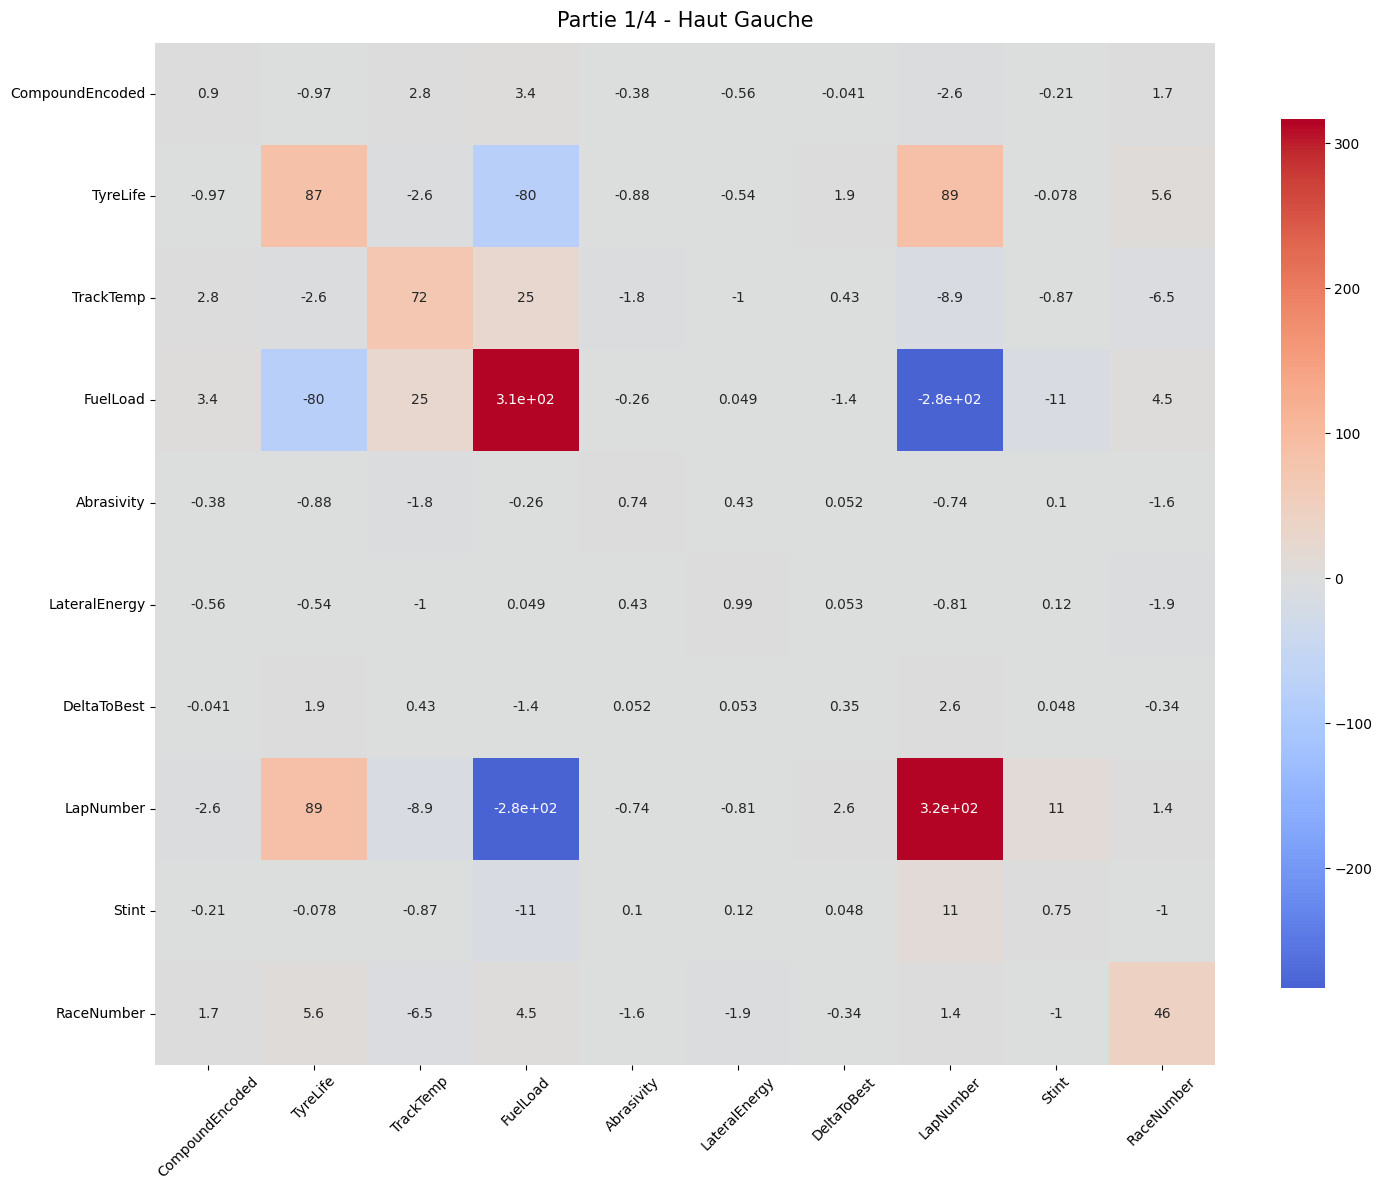

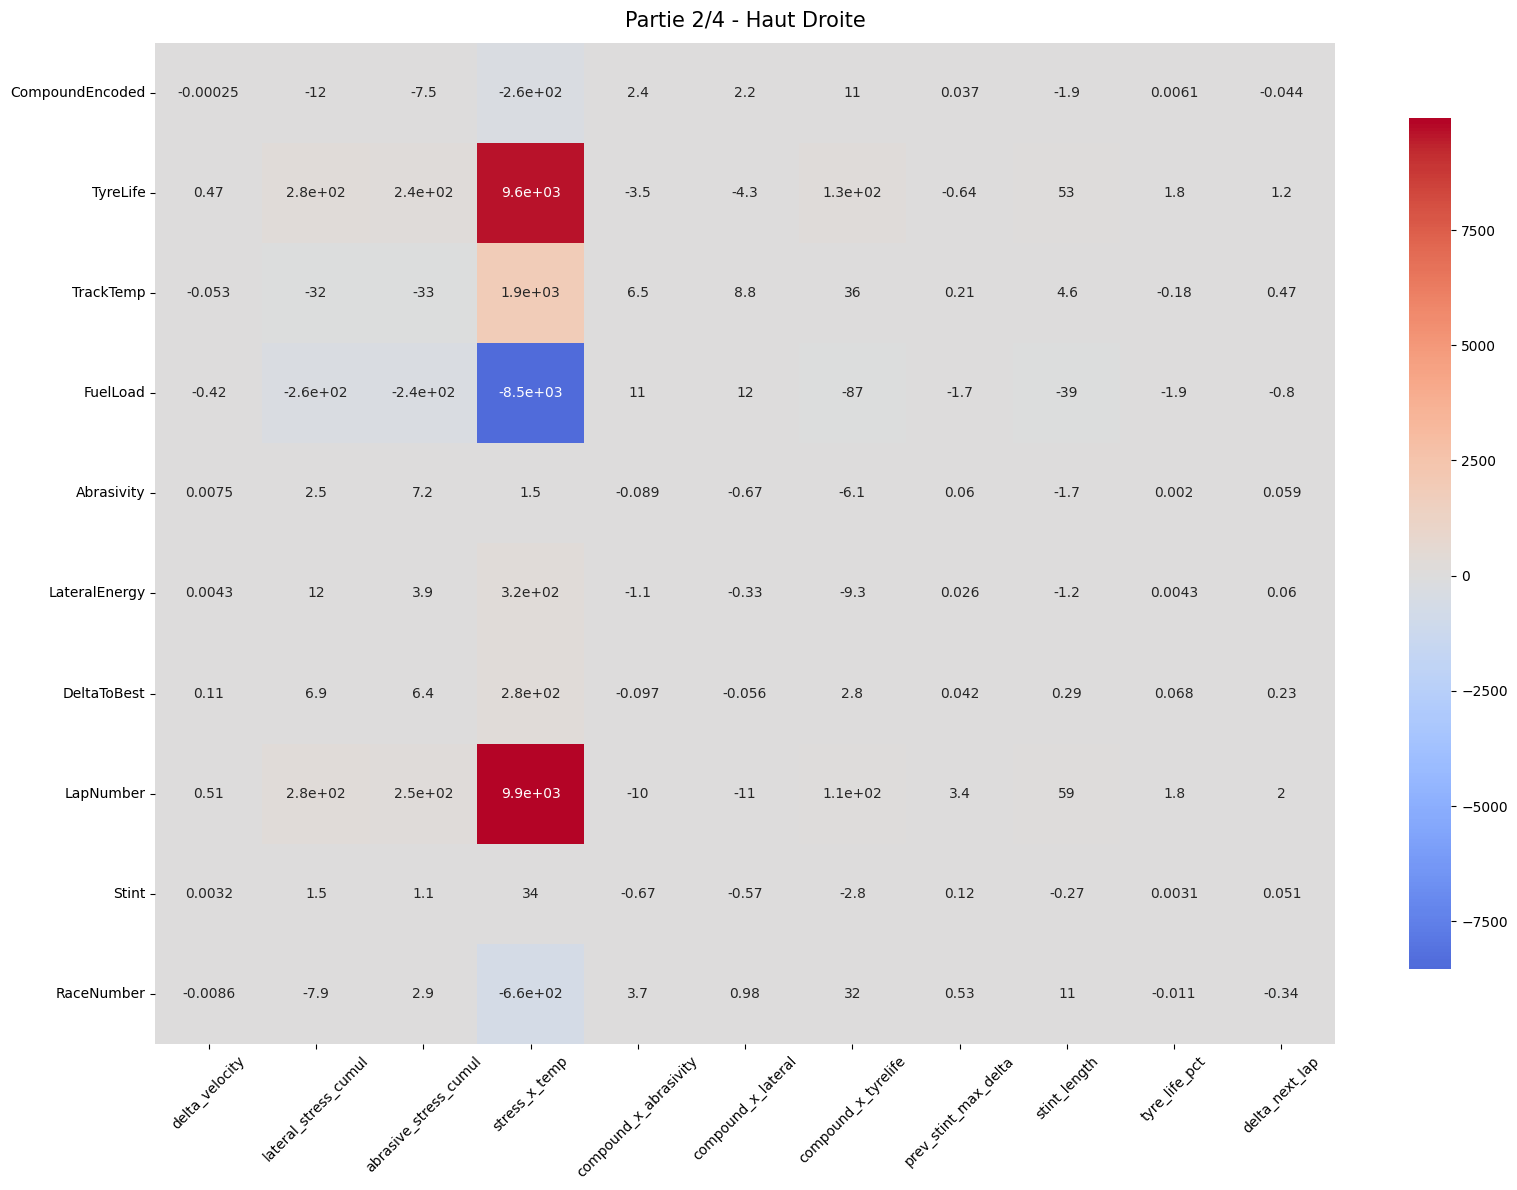

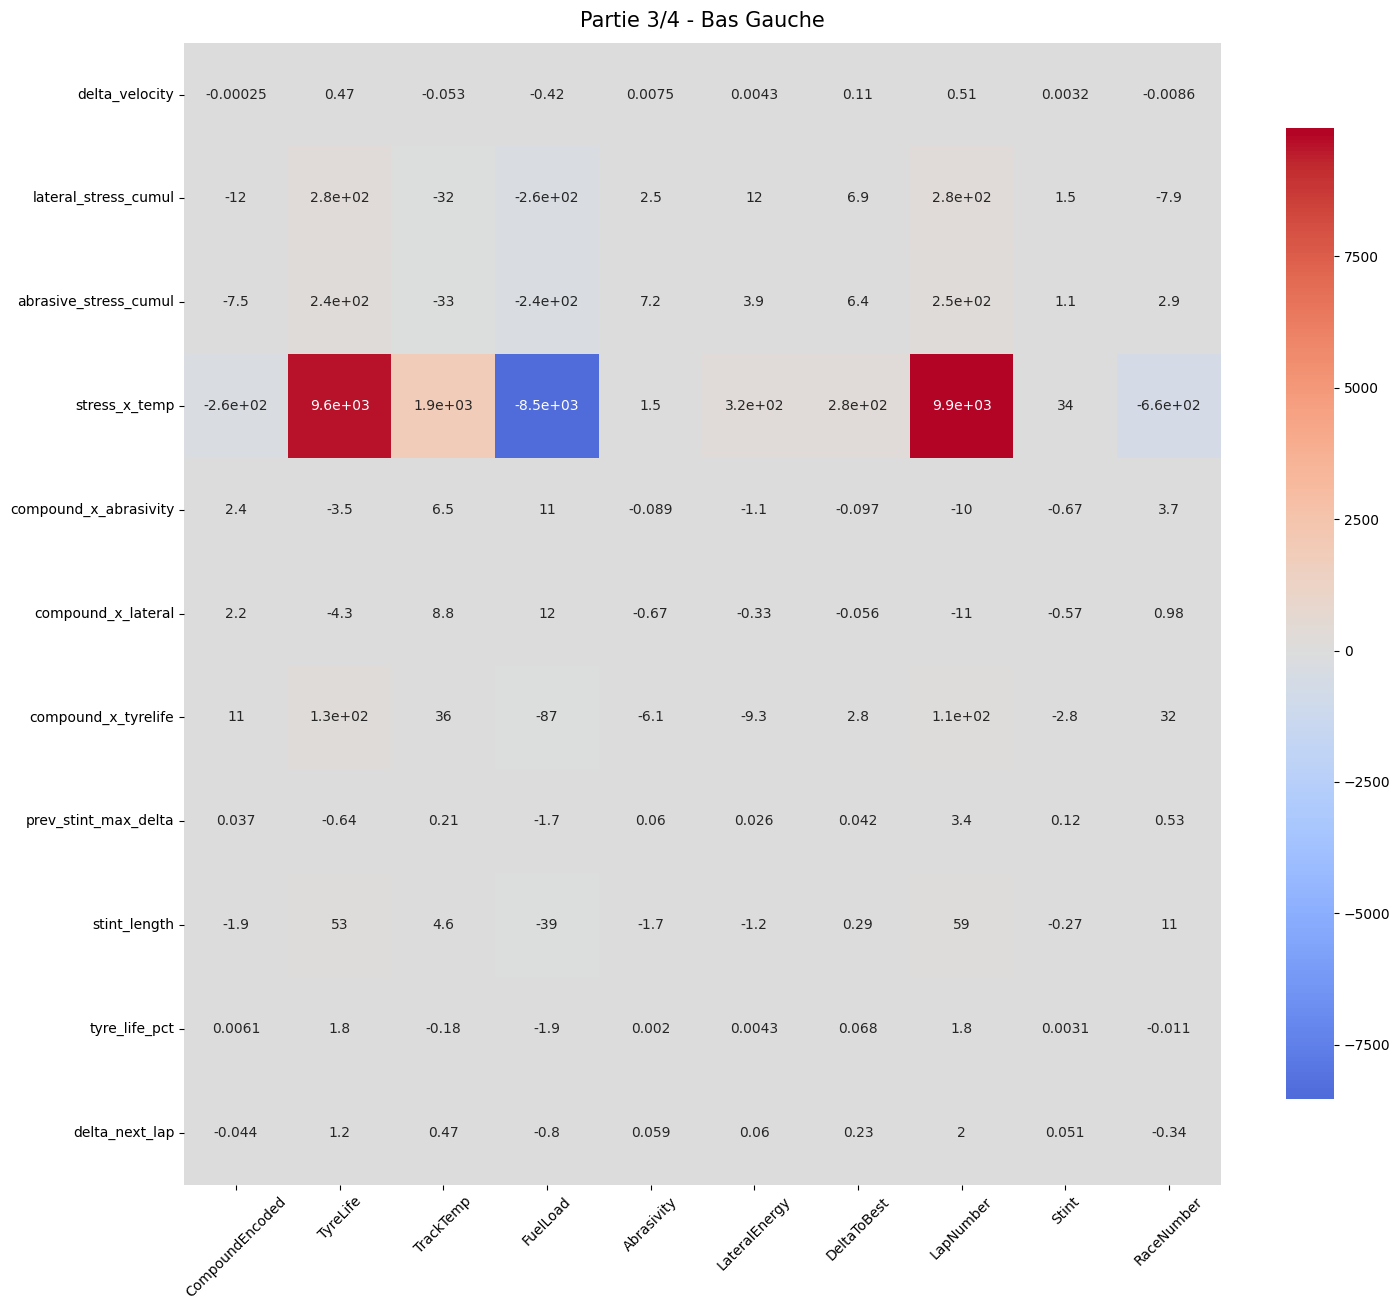

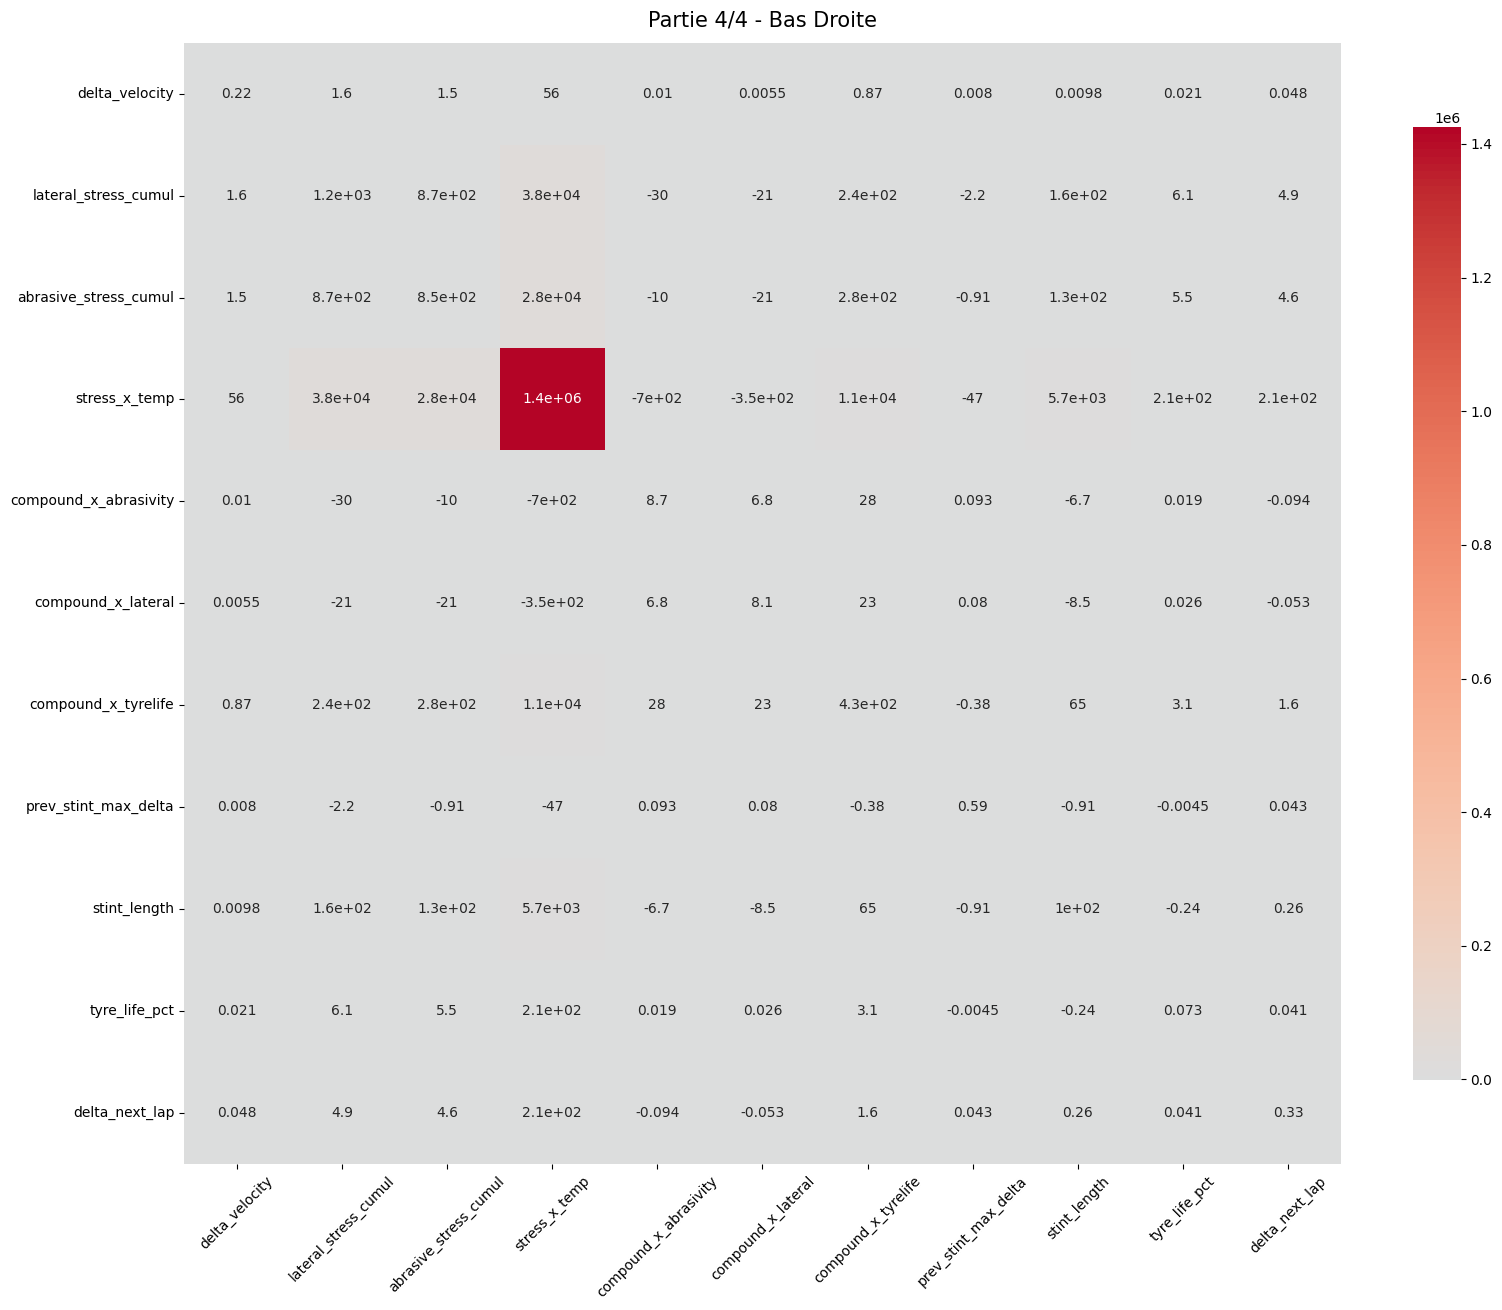

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

cov = df_preprocessed.cov(numeric_only=True)

# Split the covariance matrix into 4 quadrants (2x2).
cols = cov.columns.tolist()
mid = len(cols) // 2

top_cols = cols[:mid]
bottom_cols = cols[mid:]

quadrants = [
    ("Partie 1/4 - Haut Gauche", top_cols, top_cols),
    ("Partie 2/4 - Haut Droite", top_cols, bottom_cols),
    ("Partie 3/4 - Bas Gauche", bottom_cols, top_cols),
    ("Partie 4/4 - Bas Droite", bottom_cols, bottom_cols),
]

for title, row_cols, col_cols in quadrants:
    cov_part = cov.loc[row_cols, col_cols]

    plt.figure(figsize=(max(8, 1.5 * len(col_cols)), max(6, 1.2 * len(row_cols))))
    ax = sns.heatmap(
        cov_part,
        annot=True,
        fmt=".2g",
        cmap="coolwarm",
        center=0,
        annot_kws={"size": 10},
        cbar_kws={"shrink": 0.85}
    )
    ax.set_title(title, fontsize=15, pad=12)
    ax.tick_params(axis="x", labelrotation=45, labelsize=10)
    ax.tick_params(axis="y", labelrotation=0, labelsize=10)
    plt.tight_layout()
    plt.show()

In [52]:
test=df_preprocessed[df_preprocessed["RaceNumber"]==3]
print(test["CompoundEncoded"].value_counts())

CompoundEncoded
3    652
4    146
5     13
Name: count, dtype: int64


In [ ]:
# Split train/test on three different circuits present in the data
# We take the 3 most represented race numbers so the test set really contains 3 circuits.
from sklearn.model_selection import train_test_split


Test_races=[11,10,1]

df_test = df_preprocessed[df_preprocessed['RaceNumber'].isin(Test_races)].copy()
df_train = df_preprocessed[~df_preprocessed['RaceNumber'].isin(Test_races)].copy()

feature_cols = [
    col for col in df_preprocessed.columns
    if col != 'delta_next_lap'  and pd.api.types.is_numeric_dtype(df_preprocessed[col])
]

X_train,y_train,X_test,y_test = train_test_split(df_preprocessed, df_preprocessed['delta_next_lap'], test_size=0.2, random_state=42)

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape :', X_test.shape, y_test.shape)
print('Test races :', Test_races)
print('Test race counts:')
print(df_test['RaceNumber'].value_counts().sort_index())
print('Feature columns:', feature_cols)

Train shape: (14546, 21) (14546,)
Test shape : (3253, 21) (3253,)
Test races : [11, 10, 1]
Test race counts:
RaceNumber
1      977
10    1066
11    1210
Name: count, dtype: int64
Feature columns: ['CompoundEncoded', 'TyreLife', 'TrackTemp', 'FuelLoad', 'Abrasivity', 'LateralEnergy', 'DeltaToBest', 'LapNumber', 'Stint', 'RaceNumber', 'TeamEncoded', 'delta_velocity', 'lateral_stress_cumul', 'abrasive_stress_cumul', 'stress_x_temp', 'compound_x_abrasivity', 'compound_x_lateral', 'compound_x_tyrelife', 'prev_stint_max_delta', 'stint_length', 'tyre_life_pct']


In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# --- Classical ML models ---
models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        max_features='sqrt',
        bootstrap=True,
        
    ),
    'XGBoost': XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        n_jobs=-1,
    ),
}

# Train + evaluate classical models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
results_df = pd.DataFrame(results)
print(results_df)
best_model = models["RandomForest"]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000862 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2519
[LightGBM] [Info] Number of data points in the train set: 14546, number of used features: 21
[LightGBM] [Info] Start training from score 0.544234
          Model       MAE      RMSE        R2
0  RandomForest  0.290160  0.412611  0.531155
1       XGBoost  0.277688  0.404542  0.549313
2      LightGBM  0.268837  0.395945  0.568266


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# 1. Définition du modèle
rf = RandomForestRegressor(random_state=42)

# 2. Grille de paramètres "intelligente"
# On utilise des distributions pour le RandomizedSearch
param_dist = {
    'n_estimators': [100, 300,400],
    'max_depth': [20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4,8],
}

# 3. Configuration de la recherche
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,           # Limite à 10 combinaisons aléatoires pour aller vite
    cv=3,                # 3-fold cross-validation au lieu de 5 pour gagner du temps
    scoring='neg_mean_squared_error',
    n_jobs=-1,           # Utilise tous les cœurs de votre processeur
    verbose=2,           # Affiche la progression
    random_state=42
)

# 4. Entraînement
random_search.fit(X_train, y_train)

# 5. Résultats
print(f"Meilleurs paramètres : {random_search.best_params_}")
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred) ** 0.5)
print(r2_score(y_test, y_pred))


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_depth': 20}
0.23083306411089555
0.31812663420135656
0.7527456017684663


In [27]:
import joblib

# Sauvegarde du meilleur modèle trouvé par la rencherche
joblib.dump(best_model, 'mon_model_rf_new.pkl')

print("Modèle sauvegardé avec succès sous le nom 'mon_model_rf_new.pkl'")

Modèle sauvegardé avec succès sous le nom 'mon_model_rf_new.pkl'


In [49]:
from IPython.display import display


def get_feature_importance_df(model, feature_names):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(np.ravel(model.coef_))
    else:
        raise ValueError(f"Le modèle {type(model).__name__} ne fournit pas d'importance native exploitable.")

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    importance_df["Rank"] = np.arange(1, len(importance_df) + 1)
    importance_df = importance_df[["Feature", "Importance", "Rank"]]
    return importance_df


feature_importance_tables = {}

for name, model in models.items():
    importance_df = get_feature_importance_df(best_model, feature_cols)
    feature_importance_tables[name] = importance_df
    print(f"\nFeature importance - {name}")
    display(importance_df)



Feature importance - RandomForest


,Feature,Importance,Rank
0,DeltaToBest,0.605848,1
1,tyre_life_pct,0.149940,2
2,delta_velocity,0.048951,3
3,prev_stint_max_delta,0.021047,4
4,TrackTemp,0.020958,5
5,stint_length,0.016568,6
6,stress_x_temp,0.015562,7
7,LapNumber,0.015000,8
8,FuelLoad,0.014458,9
9,compound_x_tyrelife,0.013622,10



Feature importance - XGBoost


,Feature,Importance,Rank
0,DeltaToBest,0.605848,1
1,tyre_life_pct,0.149940,2
2,delta_velocity,0.048951,3
3,prev_stint_max_delta,0.021047,4
4,TrackTemp,0.020958,5
5,stint_length,0.016568,6
6,stress_x_temp,0.015562,7
7,LapNumber,0.015000,8
8,FuelLoad,0.014458,9
9,compound_x_tyrelife,0.013622,10



Feature importance - LightGBM


,Feature,Importance,Rank
0,DeltaToBest,0.605848,1
1,tyre_life_pct,0.149940,2
2,delta_velocity,0.048951,3
3,prev_stint_max_delta,0.021047,4
4,TrackTemp,0.020958,5
5,stint_length,0.016568,6
6,stress_x_temp,0.015562,7
7,LapNumber,0.015000,8
8,FuelLoad,0.014458,9
9,compound_x_tyrelife,0.013622,10


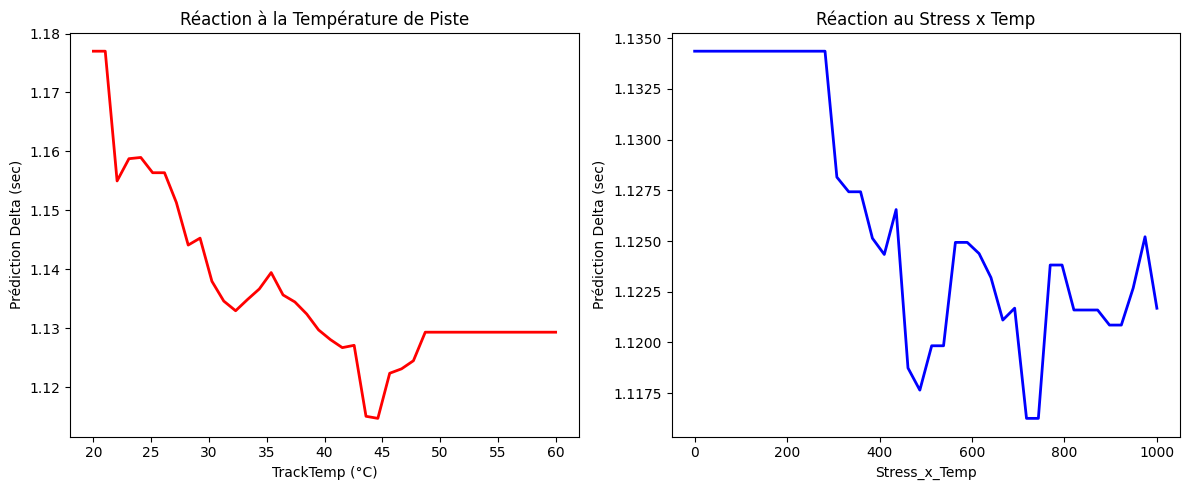

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_stress_test(model, base_row, feature_name, range_values):
    """
    Fait varier une seule caractéristique pour voir l'impact sur la prédiction.
    """
    results = []
    test_df = pd.concat([base_row] * len(range_values), ignore_index=True)
    test_df[feature_name] = range_values
    
    # Prédiction
    predictions = model.predict(test_df)
    
    return range_values, predictions

# 1. On isole un tour de référence (ex: tour 15 du GP de Hongrie)
# Assure-toi que 'X_test' contient tes données de test
reference_lap = X_test.iloc[[10]] 

# 2. On définit une plage de température de piste (de 20°C à 60°C)
temps = np.linspace(20, 60, 40)

# 3. On lance le test sur TrackTemp et stress_x_temp
val_temp, pred_temp = run_stress_test(best_model, reference_lap,'TrackTemp', temps)
val_stress, pred_stress = run_stress_test(best_model, reference_lap, 'stress_x_temp', np.linspace(0, 1000, 40))

# 4. Visualisation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(val_temp, pred_temp, color='red', lw=2)
plt.title('Réaction à la Température de Piste')
plt.xlabel('TrackTemp (°C)')
plt.ylabel('Prédiction Delta (sec)')

plt.subplot(1, 2, 2)
plt.plot(val_stress, pred_stress, color='blue', lw=2)
plt.title('Réaction au Stress x Temp')
plt.xlabel('Stress_x_Temp')
plt.ylabel('Prédiction Delta (sec)')

plt.tight_layout()
plt.show()